# 4. Loss Functions

The **Loss Function** (or Cost Function) tells the network how "wrong" it is.
Minimizing this number is the goal of training.
Different tasks need different loss functions!

In [5]:
import torch
import torch.nn as nn
import numpy as np

## 1. Regression: Mean Squared Error (MSE)

Used when predicting a continuous number (e.g., house price).

$MSE = \frac{1}{N} \sum (y_{pred} - y_{true})^2$

In [6]:
y_pred = torch.tensor([2.5, 0.0, 2.0])
y_true = torch.tensor([3.0, -0.5, 2.0])

criterion = nn.MSELoss()
loss = criterion(y_pred, y_true)

print(f"Predictions: {y_pred}")
print(f"Targets: {y_true}")
print(f"MSE Loss: {loss.item():.4f}")

# Manual calculation
manual_loss = ((y_pred - y_true)**2).mean()
print(f"Manual MSE: {manual_loss.item():.4f}")

Predictions: tensor([2.5000, 0.0000, 2.0000])
Targets: tensor([ 3.0000, -0.5000,  2.0000])
MSE Loss: 0.1667
Manual MSE: 0.1667


## 2. Classification: Cross Entropy Loss

Used when predicting classes (e.g., Cat, Dog, Bird).
It combines **LogSoftmax** and **NLLLoss**.

$CE = -\sum y_{true} \cdot \log(p_{pred})$

**Important**: PyTorch's `CrossEntropyLoss` expects **raw logits** (scores before Softmax), not probabilities!

## 4. Deep Dive: Cross Entropy Step-by-Step

Let's break down exactly what happens inside Cross Entropy Loss!

### Step 1: Softmax - Converting Logits to Probabilities

Neural networks output raw scores called **logits**. We use **Softmax** to convert them to probabilities:

$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}$

This ensures all probabilities sum to 1.0!

In [7]:
# Single sample: predicting Cat, Dog, or Bird
logits = torch.tensor([2.0, 1.0, 0.1])

# Manual Softmax calculation
exp_logits = torch.exp(logits)
probabilities = exp_logits / exp_logits.sum()

print("Logits:", logits)
print("\nExponentials:")
print(f"  e^2.0 = {exp_logits[0]:.3f}")
print(f"  e^1.0 = {exp_logits[1]:.3f}")
print(f"  e^0.1 = {exp_logits[2]:.3f}")
print(f"  Sum = {exp_logits.sum():.3f}")

print("\nProbabilities after Softmax:")
print(f"  P(Cat)  = {probabilities[0]:.3f} ({probabilities[0]*100:.1f}%)")
print(f"  P(Dog)  = {probabilities[1]:.3f} ({probabilities[1]*100:.1f}%)")
print(f"  P(Bird) = {probabilities[2]:.3f} ({probabilities[2]*100:.1f}%)")
print(f"\nSum of probabilities: {probabilities.sum():.6f}")

# Verify with PyTorch's Softmax
softmax = nn.Softmax(dim=0)
probs_torch = softmax(logits)
print(f"\nPyTorch Softmax: {probs_torch}")

Logits: tensor([2.0000, 1.0000, 0.1000])

Exponentials:
  e^2.0 = 7.389
  e^1.0 = 2.718
  e^0.1 = 1.105
  Sum = 11.213

Probabilities after Softmax:
  P(Cat)  = 0.659 (65.9%)
  P(Dog)  = 0.242 (24.2%)
  P(Bird) = 0.099 (9.9%)

Sum of probabilities: 1.000000

PyTorch Softmax: tensor([0.6590, 0.2424, 0.0986])


### Step 2: Cross Entropy - Correct Prediction

When the model predicts correctly with **high confidence**, loss is **low**.

$\text{CE} = -\sum y_{\text{true}} \cdot \log(p_{\text{pred}})$

For a single correct class, this simplifies to: $\text{CE} = -\log(p_{\text{correct class}})$

In [8]:
# Scenario: Image is a Cat (class 0), model predicts Cat strongly
logits = torch.tensor([[2.0, 1.0, 0.1]])  # Shape: (1, 3)
target = torch.tensor([0])  # True class: Cat

# Step 1: Get probabilities
probs = torch.softmax(logits, dim=1)
print("Predicted probabilities:")
print(f"  Cat:  {probs[0][0]:.4f} (65.9%)")
print(f"  Dog:  {probs[0][1]:.4f} (24.2%)")
print(f"  Bird: {probs[0][2]:.4f} (9.9%)")

# Step 2: Manually calculate Cross Entropy
# Since true class is 0 (Cat), we only care about P(Cat)
prob_correct_class = probs[0][target[0]]
manual_ce = -torch.log(prob_correct_class)

print(f"\nProbability of correct class (Cat): {prob_correct_class:.4f}")
print(f"Manual Cross Entropy: -log({prob_correct_class:.4f}) = {manual_ce:.4f}")

# Step 3: Verify with PyTorch
criterion = nn.CrossEntropyLoss()
loss = criterion(logits, target)
print(f"PyTorch Cross Entropy: {loss.item():.4f}")

print("\n✅ Loss is LOW because prediction was CORRECT and CONFIDENT!")

Predicted probabilities:
  Cat:  0.6590 (65.9%)
  Dog:  0.2424 (24.2%)
  Bird: 0.0986 (9.9%)

Probability of correct class (Cat): 0.6590
Manual Cross Entropy: -log(0.6590) = 0.4170
PyTorch Cross Entropy: 0.4170

✅ Loss is LOW because prediction was CORRECT and CONFIDENT!


### Step 3: Cross Entropy - Wrong Prediction

When the model predicts **incorrectly** with high confidence, loss is **very high**!

This heavily penalizes confident mistakes.

In [9]:
# Scenario: Image is a Bird (class 2), but model predicts Cat very strongly!
logits = torch.tensor([[4.0, 0.0, 0.0]])  # Model is 95%+ sure it's a Cat
target = torch.tensor([2])  # True class: Bird

# Step 1: Get probabilities
probs = torch.softmax(logits, dim=1)
print("Predicted probabilities:")
print(f"  Cat:  {probs[0][0]:.4f} ({probs[0][0]*100:.1f}%)")
print(f"  Dog:  {probs[0][1]:.4f} ({probs[0][1]*100:.1f}%)")
print(f"  Bird: {probs[0][2]:.4f} ({probs[0][2]*100:.1f}%) ← TRUE CLASS")

# Step 2: Calculate Cross Entropy manually
prob_correct_class = probs[0][target[0]]
manual_ce = -torch.log(prob_correct_class)

print(f"\nProbability of correct class (Bird): {prob_correct_class:.4f}")
print(f"Manual Cross Entropy: -log({prob_correct_class:.4f}) = {manual_ce:.4f}")

# Verify with PyTorch
criterion = nn.CrossEntropyLoss()
loss = criterion(logits, target)
print(f"PyTorch Cross Entropy: {loss.item():.4f}")

print("\n❌ Loss is VERY HIGH because model was WRONG and CONFIDENT!")

Predicted probabilities:
  Cat:  0.9647 (96.5%)
  Dog:  0.0177 (1.8%)
  Bird: 0.0177 (1.8%) ← TRUE CLASS

Probability of correct class (Bird): 0.0177
Manual Cross Entropy: -log(0.0177) = 4.0360
PyTorch Cross Entropy: 4.0360

❌ Loss is VERY HIGH because model was WRONG and CONFIDENT!


### Step 4: Understanding the Math

Why does $-\log(p)$ work so well?

Let's visualize how loss changes with prediction confidence:

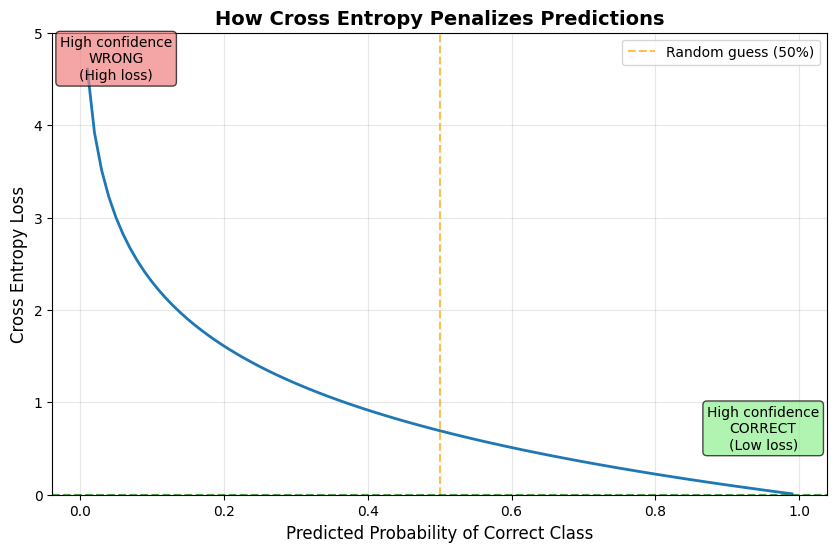

Key insights:
  • P = 1.0 → Loss ≈ 0 (perfect prediction)
  • P = 0.5 → Loss ≈ 0.69 (random guess)
  • P → 0 → Loss → ∞ (confident but wrong!)


In [10]:
import matplotlib.pyplot as plt

# Range of probabilities from near 0 to 1
probabilities = torch.linspace(0.01, 0.99, 100)
losses = -torch.log(probabilities)

plt.figure(figsize=(10, 6))
plt.plot(probabilities.numpy(), losses.numpy(), linewidth=2)
plt.xlabel('Predicted Probability of Correct Class', fontsize=12)
plt.ylabel('Cross Entropy Loss', fontsize=12)
plt.title('How Cross Entropy Penalizes Predictions', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add annotations
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='Random guess (50%)')
plt.axhline(y=0, color='green', linestyle='--', alpha=0.7)

# Annotate key points
plt.text(0.95, 0.5, 'High confidence\nCORRECT\n(Low loss)', 
         fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
plt.text(0.05, 4.5, 'High confidence\nWRONG\n(High loss)', 
         fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.legend()
plt.ylim(0, 5)
plt.show()

print("Key insights:")
print("  • P = 1.0 → Loss ≈ 0 (perfect prediction)")
print("  • P = 0.5 → Loss ≈ 0.69 (random guess)")
print("  • P → 0 → Loss → ∞ (confident but wrong!)")

### Step 5: Batch Cross Entropy

In practice, we compute loss over multiple samples and take the mean.

In [11]:
# Batch of 3 images
logits = torch.tensor([
    [2.0, 1.0, 0.1],   # Sample 1: Predicts Cat
    [0.5, 2.5, 0.3],   # Sample 2: Predicts Dog  
    [4.0, 0.0, 0.0]    # Sample 3: Predicts Cat
])
targets = torch.tensor([0, 1, 2])  # True: Cat, Dog, Bird

# Calculate loss for each sample individually
probs = torch.softmax(logits, dim=1)

print("Individual sample analysis:\n")
for i in range(3):
    true_class = targets[i].item()
    prob_true = probs[i][true_class]
    loss_i = -torch.log(prob_true)
    
    predicted_class = logits[i].argmax().item()
    correct = "✅" if predicted_class == true_class else "❌"
    
    print(f"Sample {i+1}: {correct}")
    print(f"  True class: {true_class}, Predicted: {predicted_class}")
    print(f"  P(true class) = {prob_true:.4f}")
    print(f"  Loss = {loss_i:.4f}\n")

# PyTorch computes mean of all losses
criterion = nn.CrossEntropyLoss()
total_loss = criterion(logits, targets)

# Manual mean
manual_losses = torch.tensor([loss_i for i in range(3)])
for i in range(3):
    manual_losses[i] = -torch.log(probs[i][targets[i]])
    
mean_loss = manual_losses.mean()

print(f"Average loss (manual): {mean_loss:.4f}")
print(f"PyTorch CrossEntropyLoss: {total_loss:.4f}")

Individual sample analysis:

Sample 1: ✅
  True class: 0, Predicted: 0
  P(true class) = 0.6590
  Loss = 0.4170

Sample 2: ✅
  True class: 1, Predicted: 1
  P(true class) = 0.8025
  Loss = 0.2200

Sample 3: ❌
  True class: 2, Predicted: 0
  P(true class) = 0.0177
  Loss = 4.0360

Average loss (manual): 1.5577
PyTorch CrossEntropyLoss: 1.5577


### Step 6: Why Not Just Use Accuracy?

Cross Entropy is **differentiable** and provides **gradient information** for learning.

Accuracy only tells you if you're right or wrong, but not **how confident** you should be.

In [12]:
# Two scenarios: both predict correctly, but with different confidence

# Scenario A: Hesitant but correct
logits_a = torch.tensor([[1.1, 0.9, 0.8]])  # Barely predicts class 0
target = torch.tensor([0])

probs_a = torch.softmax(logits_a, dim=1)
loss_a = nn.CrossEntropyLoss()(logits_a, target)

# Scenario B: Confident and correct
logits_b = torch.tensor([[3.0, 0.0, 0.0]])  # Very confident about class 0
probs_b = torch.softmax(logits_b, dim=1)
loss_b = nn.CrossEntropyLoss()(logits_b, target)

print("Both scenarios predict class 0 correctly:\n")

print("Scenario A (Hesitant):")
print(f"  Probabilities: {probs_a[0]}")
print(f"  P(class 0) = {probs_a[0][0]:.4f}")
print(f"  Cross Entropy Loss: {loss_a:.4f}\n")

print("Scenario B (Confident):")
print(f"  Probabilities: {probs_b[0]}")
print(f"  P(class 0) = {probs_b[0][0]:.4f}")
print(f"  Cross Entropy Loss: {loss_b:.4f}\n")

print("📊 Analysis:")
print(f"  Accuracy: Both are 100% correct")
print(f"  Cross Entropy: Rewards confidence! ({loss_b:.4f} < {loss_a:.4f})")

Both scenarios predict class 0 correctly:

Scenario A (Hesitant):
  Probabilities: tensor([0.3907, 0.3199, 0.2894])
  P(class 0) = 0.3907
  Cross Entropy Loss: 0.9398

Scenario B (Confident):
  Probabilities: tensor([0.9094, 0.0453, 0.0453])
  P(class 0) = 0.9094
  Cross Entropy Loss: 0.0949

📊 Analysis:
  Accuracy: Both are 100% correct
  Cross Entropy: Rewards confidence! (0.0949 < 0.9398)


In [13]:
## 5. Summary
logits = torch.tensor([[2.0, 1.0, 0.1],   # Pred: Cat (class 0)
                       [0.5, 2.5, 0.3],   # Pred: Dog (class 1)
                       [4.0, 0.0, 0.0]])  # Pred: Cat (class 0)

targets = torch.tensor([0, 1, 2]) # True: Cat, Dog, Bird

criterion = nn.CrossEntropyLoss()
loss = criterion(logits, targets)

print(f"Logits:\n{logits}")
print(f"Targets: {targets}")
print(f"Cross Entropy Loss: {loss.item():.4f}")

# Why is loss high? The 3rd sample predicted Cat (score 4.0) but was Bird (class 2)!

Logits:
tensor([[2.0000, 1.0000, 0.1000],
        [0.5000, 2.5000, 0.3000],
        [4.0000, 0.0000, 0.0000]])
Targets: tensor([0, 1, 2])
Cross Entropy Loss: 1.5577
